#Install Library

In [2]:
!pip install Sastrawi feedparser google-play-scraper transformers torch

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 1.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.5/81.5 kB 6.9 MB/s eta 0:00:00
  Created wheel for sgmllib3k: filename=sgmllib3k-1.0.0-py3-none-any.whl size=6046 sha256=d07741ff0cb926a5069951a8376553755d243e57c2692bcf361cfc75a8bdff9d
  Stored in directory: /root/.cache/pip/wheels/03/f5/1a/23761066dac1d0e8e683e5fdb27e12de53209d05a4a37e6246
Successfully built sgmllib3k


#Import Library

In [3]:
import pandas as pd
from nltk.sentiment import SentimentIntensityAnalyzer
import pandas as pd
import nltk
from transformers import pipeline
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report
from sklearn.tree import DecisionTreeClassifier
from nltk.sentiment import SentimentIntensityAnalyzer
import pandas as pd
from nltk.sentiment import SentimentIntensityAnalyzer
import pandas as pd
import nltk
import nltk
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline
import pandas as pd
import numpy as np
import re
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from nltk.stem import PorterStemmer
from nltk.stem.snowball import SnowballStemmer
import string
import nltk
from PIL import Image
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
import nltk
from nltk.corpus import stopwords as nltk_stopwords
from google_play_scraper import reviews, Sort
pd.set_option('display.max_colwidth', None)
import feedparser

nltk.download('punkt')
nltk.download('stopwords')

stopword_id = set(nltk_stopwords.words('indonesian'))

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


#Read Data

In [4]:
result, continuation_token = reviews(
    'com.telkomsel.telkomselcm',
    lang='id',
    country='id',
    sort=Sort.NEWEST,
    count=5000)
df_playstore = pd.DataFrame(result)

In [5]:
df_playstore

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,ab3c40f8-3341-406b-bbf7-eeabbf89a00d,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,sekarang jadi lemot lama buka nya..,1,0,9.2.1,2026-07-10 10:05:19,"Hai Kak Maman, mohon maaf ya kak jika aplikasi dirasa agak lambat, Kami memahami ketidaknyamanan Kakak. Bisa coba update ke versi terbaru atau cek koneksi internet terlebih dahulu boleh coba clear cache juga. Jika masih terkendala, silakan hubungi kami melalui email cs@telkomsel.com atau ke 188 . Kami siap bantu ya 😊 -Ken",2026-07-10 14:06:21,9.2.1
1,1fa573f3-0e9f-4612-9d04-a0cce3881dfe,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,jaringan paling buruk se +62,1,0,9.2.1,2026-07-10 10:01:54,"Hai Kak Eko, mohon maaf atas ketidaknyamanannya. Terkait kendala jaringan yang dialami, Kakak bisa coba melakukan restart handphone terlebih dahulu ya. Jika masih mengalami kendala yang sama, silakan hubungi kami melalui email cs@telkomsel.com atau ke Call Center 188. Kami siap bantu ya 😊 -Ken",2026-07-10 13:21:05,9.2.1
2,777ceb0f-c06c-4f19-846c-9a6117968c6c,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,"saya baru ngisi pulsa 110 ribu untuk 65gb data internet, sudah 5 menit lebih setelah transaksi berhasil, tapi paket internet saya belum terisi",1,0,9.2.1,2026-07-10 10:01:35,"Hai Kak Indah, mohon maaf atas kendala terkait saldo yang sudah terpotong namun paket belum diterima. Agar kami dapat membantu melakukan pengecekan lebih lanjut, silakan hubungi kami melalui email cs@telkomsel.com atau ke Call Center 188. Kami tunggu ya😊 -Ken",2026-07-10 14:07:29,9.2.1
3,e62372d5-550f-4c41-8bf0-7005e90629b2,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,sangat bagus dan hemat,5,0,9.2.1,2026-07-10 09:59:13,None,NaT,9.2.1
4,7c17466d-398f-442b-a112-b0dbedb16b83,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,aplikasi jelek. berat. tidak berfungsi dengan baik sama seperti signalnya yg gak ada bagus bagusnya. aplikasi apa gak bisa di buka gini. sekelas telkomsel layanan dan jaringannya sama kaya esia. pekerja anda apakah semua lulusan smp? kok kerjanya seperti ini.. yang bener kita pindah indosat semua saja,1,0,9.2.1,2026-07-10 09:56:24,"Hai Kak Ipan, maaf atas kendalanya. Agar aplikasi lebih optimal, silakan unduh MyTelkomsel Basic di PlayStore. Untuk masalah sinyal, coba restart HP Kakak dulu ya. Jika kendala masih berlanjut, mohon hubungi kami melalui email cs@telkomsel.com atau Call Center 188. Kami siap membantu 😊 -Ken",2026-07-10 14:33:35,9.2.1
...,...,...,...,...,...,...,...,...,...,...,...
4995,951c7ef2-acd8-4a44-9572-9348b7941efa,Merion Giyai,https://play-lh.googleusercontent.com/a-/ALV-UjUsMF8Pwj27KAwz3g08vD7dCqUSxd1dNpoceeMc9AloMGGPgXtA,mantap,5,0,9.2.1,2026-06-27 04:58:25,None,NaT,9.2.1
4996,60df2dc6-f765-494d-a2e6-ce9e384ba080,Husda com Husda com,https://play-lh.googleusercontent.com/a/ACg8ocLZuzTOPm9Oou-bXOtVN3GucB24bxN2fvqKRhmVFnYIuOqs8Q=mo,bagus,4,0,9.2.1,2026-06-27 04:45:03,None,NaT,9.2.1
4997,1bd91cae-3c38-4927-aede-6ba7f178a3dd,Nebula Zaki,https://play-lh.googleusercontent.com/a-/ALV-UjUSrbJSfO6ZRivB08ig4bJ6HztC8-HoLsDRd-7vkV4rDKHvg0g,"harga mahal, jaringan sering lelet, provider macam apa ini",5,0,9.2.1,2026-06-27 04:41:21,None,NaT,9.2.1
4998,e9f63546-b092-41ba-a3fa-1ee9884b44de,Tria Juliawati,https://play-lh.googleusercontent.com/a-/ALV-UjUn6444_XsX9dKiU9naU_ZXK481PBO2jlKD18PDt7FGXlhBP4t0,"masuk aplikasi lemot,delay,mentok logo padahal sinyal bagus",1,0,None,2026-06-27 04:40:54,"Hai Kak Tria, mohon maaf ya kak jika aplikasi dirasa 

#Data Understanding (EDA)

In [6]:
df = df_playstore[['content']].copy()

##Cek Missing Value

In [7]:
df.isnull().sum()

,0
content,0


##Data Duplikat

In [8]:
df.duplicated().sum()

np.int64(870)

In [9]:
duplicates = df[df.duplicated(subset=['content'], keep=False)]
duplicates.sort_values('content').head(20)

,content
4292,Amazing
2011,Amazing
4422,Bagus
1648,Bagus
1490,Bagus
3203,Bagus
4215,Bagus
4123,Bagus
2364,Bagus
4245,Bagus sekali


In [10]:
#drop duplicate
df.drop_duplicates(inplace=True)

##Visualisasi

###Distribusi Rating

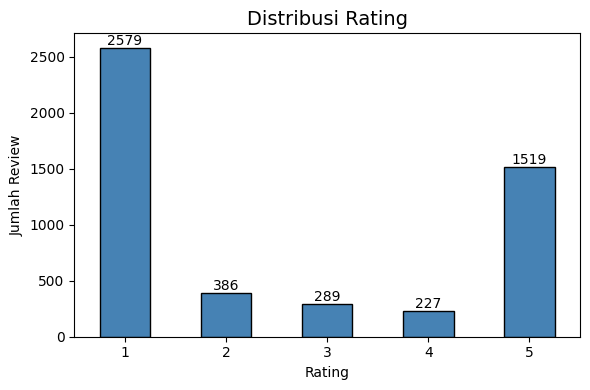

In [11]:
rating = df_playstore['score'].value_counts().sort_index()

plt.figure(figsize=(6,4))
ax = rating.plot(kind='bar', color='steelblue', edgecolor='black')

plt.title('Distribusi Rating', fontsize=14)
plt.xlabel('Rating')
plt.ylabel('Jumlah Review')
plt.xticks(rotation=0)

# Tambahkan jumlah di atas batang
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

###Distribusi Panjang Review

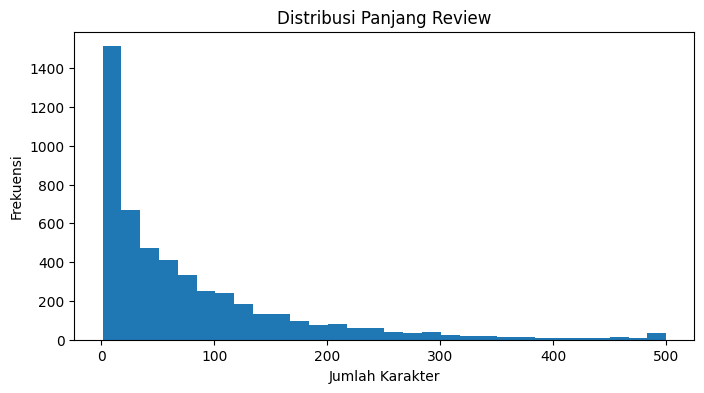

In [12]:
df_playstore['review_length'] = df_playstore['content'].str.len()

plt.figure(figsize=(8,4))
plt.hist(df_playstore['review_length'], bins=30)
plt.title('Distribusi Panjang Review')
plt.xlabel('Jumlah Karakter')
plt.ylabel('Frekuensi')
plt.show()

###Top 10 Review Terbanyak

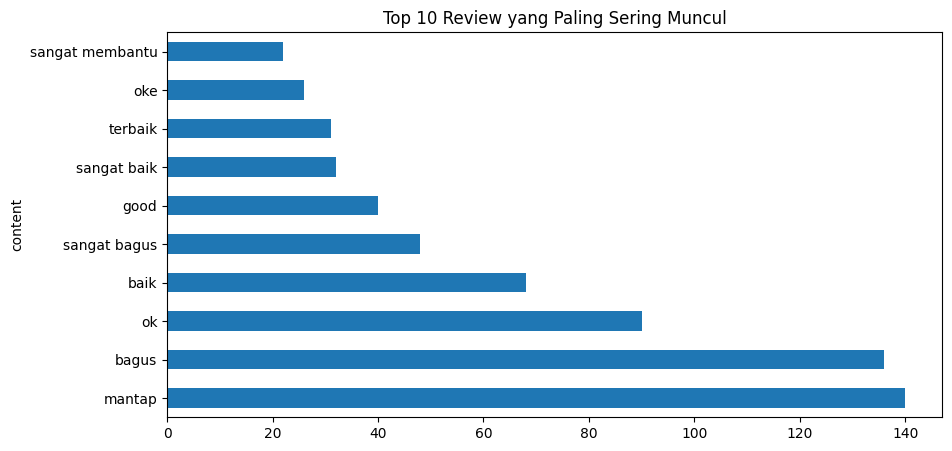

In [13]:
top_review = df_playstore['content'].value_counts().head(10)

plt.figure(figsize=(10,5))
top_review.plot(kind='barh')
plt.title('Top 10 Review yang Paling Sering Muncul')
plt.show()

#Data Preprocessing

##Cleaning

In [40]:
def cleaning(text):

    text = str(text)

    # hapus URL
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    # hapus mention
    text = re.sub(r'@\w+', '', text)

    # hapus hashtag
    text = re.sub(r'#\w+', '', text)

    # ganti titik menjadi spasi
    text = text.replace('.', ' ')

    # ganti underscore
    text = text.replace('_', ' ')

    # TAMBAHKAN INI
    text = re.sub(r"[-/]", " ", text)

    # hapus angka
    text = re.sub(r'\d+', '', text)

    # hapus emoji
    text = re.sub(
        "["
        u"\U0001F600-\U0001F64F"
        u"\U0001F300-\U0001F5FF"
        u"\U0001F680-\U0001F6FF"
        u"\U0001F1E0-\U0001F1FF"
        "]+",
        '',
        text,
        flags=re.UNICODE
    )

    # hapus tanda baca
    text = text.translate(str.maketrans('', '', string.punctuation))

    # hapus karakter selain huruf
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    # hapus spasi berlebih
    text = re.sub(r'\s+', ' ', text).strip()

    return text

df['cleaning'] = df['content'].apply(cleaning)

In [14]:
df.head(30)

,content
0,sekarang jadi lemot lama buka nya..
1,jaringan paling buruk se +62
2,"saya baru ngisi pulsa 110 ribu untuk 65gb data internet, sudah 5 menit lebih setelah transaksi berhasil, tapi paket internet saya belum terisi"
3,sangat bagus dan hemat
4,aplikasi jelek. berat. tidak berfungsi dengan baik sama seperti signalnya yg gak ada bagus bagusnya. aplikasi apa gak bisa di buka gini. sekelas telkomsel layanan dan jaringannya sama kaya esia. pekerja anda apakah semua lulusan smp? kok kerjanya seperti ini.. yang bener kita pindah indosat semua saja
5,"mksih ya my Telkomsel dan asisten AI Veronika responya cepat,"
6,aplikasi yang sangat lelet dan lemot sekali hadechh
7,tetap maju Telkomsel
8,"teknik marketingnya hebat banget, sudah isi pulsa 100k soalnya ada promo 65gb 90k malah gak bisa di beli kurang pulsa katanya, aneh banget, udah di coba beberapa kali masih tetap gak bisa. terus isi pulsa lagi Sampek 130k malah harga kuotanya yang di tawarkan di atas itu udah sinyalnya putus-putus pokok hebatlah Telkomsel nih🤣"
9,kuota pada mahal jaringan lemot


##Case Folding

In [15]:
def case_folding(text):
    if isinstance(text, str):
      lowercase_text = text.lower()
      return lowercase_text
    else:
        return text

# Re-create 'cleaning' column here, as it appears to be missing from the DataFrame
# despite being created in an earlier step.
df['cleaning'] = df['content'].apply(cleaning)

df['case_folding'] = df['cleaning'].apply(case_folding)
df.head(10)

,content,cleaning,case_folding
0,sekarang jadi lemot lama buka nya..,sekarang jadi lemot lama buka nya,sekarang jadi lemot lama buka nya
1,jaringan paling buruk se +62,jaringan paling buruk se,jaringan paling buruk se
2,"saya baru ngisi pulsa 110 ribu untuk 65gb data internet, sudah 5 menit lebih setelah transaksi berhasil, tapi paket internet saya belum terisi",saya baru ngisi pulsa ribu untuk gb data internet sudah menit lebih setelah transaksi berhasil tapi paket internet saya belum terisi,saya baru ngisi pulsa ribu untuk gb data internet sudah menit lebih setelah transaksi berhasil tapi paket internet saya belum terisi
3,sangat bagus dan hemat,sangat bagus dan hemat,sangat bagus dan hemat
4,aplikasi jelek. berat. tidak berfungsi dengan baik sama seperti signalnya yg gak ada bagus bagusnya. aplikasi apa gak bisa di buka gini. sekelas telkomsel layanan dan jaringannya sama kaya esia. pekerja anda apakah semua lulusan smp? kok kerjanya seperti ini.. yang bener kita pindah indosat semua saja,aplikasi jelek berat tidak berfungsi dengan baik sama seperti signalnya yg gak ada bagus bagusnya aplikasi apa gak bisa di buka gini sekelas telkomsel layanan dan jaringannya sama kaya esia pekerja anda apakah semua lulusan smp kok kerjanya seperti ini yang bener kita pindah indosat semua saja,aplikasi jelek berat tidak berfungsi dengan baik sama seperti signalnya yg gak ada bagus bagusnya aplikasi apa gak bisa di buka gini sekelas telkomsel layanan dan jaringannya sama kaya esia pekerja anda apakah semua lulusan smp kok kerjanya seperti ini yang bener kita pindah indosat semua saja
5,"mksih ya my Telkomsel dan asisten AI Veronika responya cepat,",mksih ya my Telkomsel dan asisten AI Veronika responya cepat,mksih ya my telkomsel dan asisten ai veronika responya cepat
6,aplikasi yang sangat lelet dan lemot sekali hadechh,aplikasi yang sangat lelet dan lemot sekali hadechh,aplikasi yang sangat lelet dan lemot sekali hadechh
7,tetap maju Telkomsel,tetap maju Telkomsel,tetap maju telkomsel
8,"teknik marketingnya hebat banget, sudah isi pulsa 100k soalnya ada promo 65gb 90k malah gak bisa di beli kurang pulsa katanya, aneh banget, udah di coba beberapa kali masih tetap gak bisa. terus isi pulsa lagi Sampek 130k malah harga kuotanya yang di tawarkan di atas itu udah sinyalnya putus-putus pokok hebatlah Telkomsel nih🤣",teknik marketingnya hebat banget sudah isi pulsa k soalnya ada promo gb k malah gak bisa di beli kurang pulsa katanya aneh banget udah di coba beberapa kali masih tetap gak bisa terus isi pulsa lagi Sampek k malah harga kuotanya yang di tawarkan di atas itu udah sinyalnya putus putus pokok hebatlah Telkomsel nih,teknik marketingnya hebat banget sudah isi pulsa k soalnya ada promo gb k malah gak bisa di beli kurang pulsa katanya aneh banget udah di coba beberapa kali masih tetap gak bisa terus isi pulsa lagi sampek k malah harga kuotanya yang di tawarkan di atas itu udah sinyalnya putus putus pokok hebatlah telkomsel nih
9,kuota pada mahal jaringan lemot,kuota pada mahal jaringan lemot,kuota pada mahal jaringan lemot


##Tokenize

In [16]:
def tokenize(text):
    tokens = text.split()
    return tokens

df['tokenize'] = df['case_folding'].apply(tokenize)
df.head(10)

,content,cleaning,case_folding,tokenize
0,sekarang jadi lemot lama buka nya..,sekarang jadi lemot lama buka nya,sekarang jadi lemot lama buka nya,"[sekarang, jadi, lemot, lama, buka, nya]"
1,jaringan paling buruk se +62,jaringan paling buruk se,jaringan paling buruk se,"[jaringan, paling, buruk, se]"
2,"saya baru ngisi pulsa 110 ribu untuk 65gb data internet, sudah 5 menit lebih setelah transaksi berhasil, tapi paket internet saya belum terisi",saya baru ngisi pulsa ribu untuk gb data internet sudah menit lebih setelah transaksi berhasil tapi paket internet saya belum terisi,saya baru ngisi pulsa ribu untuk gb data internet sudah menit lebih setelah transaksi berhasil tapi paket internet saya belum terisi,"[saya, baru, ngisi, pulsa, ribu, untuk, gb, data, internet, sudah, menit, lebih, setelah, transaksi, berhasil, tapi, paket, internet, saya, belum, terisi]"
3,sangat bagus dan hemat,sangat bagus dan hemat,sangat bagus dan hemat,"[sangat, bagus, dan, hemat]"
4,aplikasi jelek. berat. tidak berfungsi dengan baik sama seperti signalnya yg gak ada bagus bagusnya. aplikasi apa gak bisa di buka gini. sekelas telkomsel layanan dan jaringannya sama kaya esia. pekerja anda apakah semua lulusan smp? kok kerjanya seperti ini.. yang bener kita pindah indosat semua saja,aplikasi jelek berat tidak berfungsi dengan baik sama seperti signalnya yg gak ada bagus bagusnya aplikasi apa gak bisa di buka gini sekelas telkomsel layanan dan jaringannya sama kaya esia pekerja anda apakah semua lulusan smp kok kerjanya seperti ini yang bener kita pindah indosat semua saja,aplikasi jelek berat tidak berfungsi dengan baik sama seperti signalnya yg gak ada bagus bagusnya aplikasi apa gak bisa di buka gini sekelas telkomsel layanan dan jaringannya sama kaya esia pekerja anda apakah semua lulusan smp kok kerjanya seperti ini yang bener kita pindah indosat semua saja,"[aplikasi, jelek, berat, tidak, berfungsi, dengan, baik, sama, seperti, signalnya, yg, gak, ada, bagus, bagusnya, aplikasi, apa, gak, bisa, di, buka, gini, sekelas, telkomsel, layanan, dan, jaringannya, sama, kaya, esia, pekerja, anda, apakah, semua, lulusan, smp, kok, kerjanya, seperti, ini, yang, bener, kita, pindah, indosat, semua, saja]"
5,"mksih ya my Telkomsel dan asisten AI Veronika responya cepat,",mksih ya my Telkomsel dan asisten AI Veronika responya cepat,mksih ya my telkomsel dan asisten ai veronika responya cepat,"[mksih, ya, my, telkomsel, dan, asisten, ai, veronika, responya, cepat]"
6,aplikasi yang sangat lelet dan lemot sekali hadechh,aplikasi yang sangat lelet dan lemot sekali hadechh,aplikasi yang sangat lelet dan lemot sekali hadechh,"[aplikasi, yang, sangat, lelet, dan, lemot, sekali, hadechh]"
7,tetap maju Telkomsel,tetap maju Telkomsel,tetap maju telkomsel,"[tetap, maju, telkomsel]"
8,"teknik marketingnya hebat banget, sudah isi pulsa 100k soalnya ada promo 65gb 90k malah gak bisa di beli kurang pulsa katanya, aneh banget, udah di coba beberapa kali masih tetap gak bisa. terus isi pulsa lagi Sampek 130k malah harga kuotanya yang di tawarkan di atas itu udah sinyalnya putus-putus pokok hebatlah Telkomsel nih🤣",teknik marketingnya hebat banget sudah isi pulsa k soalnya ada promo gb k malah gak bisa di beli kurang pulsa katanya aneh banget udah di coba beberapa kali masih tetap gak bisa terus isi pulsa lagi Sampek k malah harga kuotanya yang di tawarkan di atas itu udah sinyalnya putus putus pokok hebatlah Telkomsel nih,teknik marketingnya hebat banget sudah isi pulsa k soalnya ada promo gb k malah gak bisa di beli kurang pulsa katanya aneh banget udah di coba beberapa kali masih tetap gak bisa terus isi pulsa lagi sampek k malah harga kuotanya yang di tawarkan di atas itu udah sinyalnya putus putus pokok hebatlah telkomsel nih,"[teknik, marketingnya, hebat, banget, sudah, isi, pulsa, k, soalnya, ada, promo, gb, k, malah, gak, bisa, di, beli, kurang, pulsa, katanya, aneh, banget, udah, di, coba, beberapa, kali, masih, tetap, gak, bisa, terus, isi, pulsa, lagi, sampek, k, mal

In [17]:
slang_dict = {
    # Pronoun
    "sy": "saya",
    "sya": "saya",
    "gw": "saya",
    "gua": "saya",
    "gue": "saya",
    "akuh": "aku",
    "aq": "aku",
    "ak": "aku",
    "km": "kamu",
    "kmu": "kamu",
    "lu": "kamu",
    "loe": "kamu",
    "u": "kamu",

    # Negasi
    "g": "tidak",
    "ga": "tidak",
    "gak": "tidak",
    "gk": "tidak",
    "ngga": "tidak",
    "nggak": "tidak",
    "engga": "tidak",
    "enggak": "tidak",
    "tdk": "tidak",
    "tak": "tidak",

    # Singkatan umum
    "yg": "yang",
    "dg": "dengan",
    "dgn": "dengan",
    "dr": "dari",
    "krn": "karena",
    "utk": "untuk",
    "bwt": "buat",
    "jd": "jadi",
    "jdi": "jadi",
    "pdhl": "padahal",
    "trs": "terus",
    "sm": "sama",
    "klu": "kalau",
    "kalo": "kalau",
    "klo": "kalau",
    "kl": "kalau",
    "tp": "tapi",
    "tpi": "tapi",
    "bs": "bisa",
    "bsa": "bisa",
    "dpt": "dapat",
    "dapet": "dapat",
    "bkn": "bukan",
    "brp":"berapa",
    "kli":"kali",
    "gj":"tidak jelas",

    # Intensitas
    "bgt": "banget",
    "bngt": "banget",
    "bnget": "banget",
    "bgtt": "banget",
    "bgtss": "banget",

    # Waktu
    "udh": "sudah",
    "udah": "sudah",
    "sdh": "sudah",
    "blm": "belum",
    "hr": "hari",
    "hri": "hari",
    "thn": "tahun",
    "bln": "bulan",

    # Kuantitas
    "byk": "banyak",
    "bnyk": "banyak",
    "sdkt": "sedikit",

    # Lain-lain
    "aja": "saja",
    "doang": "saja",
    "cm": "cuma",
    "cmn": "cuma",
    "kyk": "seperti",
    "org": "orang",
    "ank": "anak",
    "ortu": "orang tua",
    "mrk": "mereka",
    "mnrt": "menurut",
    "smoga": "semoga",
    "moga": "semoga",
    "jgn": "jangan",
    "jngn": "jangan",
    "pk": "pakai",
    "pke": "pakai",
    "pkai": "pakai",
    "byr": "bayar",
    "akhirakhir":"akhir",

    # Istilah review aplikasi
    "app": "aplikasi",
    "apk": "aplikasi",
    "apps": "aplikasi",
    "apknya": "aplikasinya",

    "eror": "error",
    "erorr": "error",
    "errorr": "error",

    "lemot": "lambat",
    "lelet": "lambat",
    "ngelag": "lag",
    "lagg": "lag",

    "gagalin": "gagal",
    "ngeload": "memuat",
    "loading": "memuat",
    "load": "memuat",

    "loginnya": "login",
    "loginn": "login",
    "logout": "keluar",

    "otpnya": "otp",
    "verif": "verifikasi",
    "notif": "notifikasi",

    "cs": "customer service",
    "cust": "customer",
    "adminnya": "admin",

    "telkomselnya": "telkomsel",
    "mytsel": "mytelkomsel",
    "mytselnya": "mytelkomsel",
    "tsel": "telkomsel",

    "paketnya": "paket",
    "kuotanya": "kuota",
    "internetan": "internet",
    "signal": "sinyal",
    "sinyalnya": "sinyal",

    # Sapaan
    "bpk": "bapak",
    "pak": "bapak",
    "bu": "ibu",

    "abis":"habis",
    "aj":"saja",
    "ajah":"saja",
    "ajaa":"saja",

    "gpp":"tidak apa apa",
    "gapapa":"tidak apa apa",
    "gapapaa":"tidak apa apa",

    "pls":"tolong",

    "udhh":"sudah",

    "bgttt":"banget",

    "mantul":"mantap",

    "ok":"baik",

    "okey":"baik",

    "oke":"baik",

    "okee":"baik",

    "bgs":"bagus",

    "bgus":"bagus",

    "udh":"sudah",

    "smpai":"sampai",

    "trus":"terus",

    "skrg":"sekarang",

    "skrng":"sekarang",

    "jdinya":"jadi",

    "abalabal": "abal abal",
    "ajh": "saja",
    "ajhh": "saja",
    "ahir": "akhir",
    "jlek": "jelek",
    "kouta": "kuota",
    "slalu": "selalu",
    "aplnya": "aplikasi",
    "sndiri": "sendiri"
}

def normalize_slang(tokens):

    return [
        slang_dict[word] if word in slang_dict else word
        for word in tokens
    ]

df['normalize'] = df['tokenize'].apply(normalize_slang)

In [18]:
df.head(10)

,content,cleaning,case_folding,tokenize,normalize
0,sekarang jadi lemot lama buka nya..,sekarang jadi lemot lama buka nya,sekarang jadi lemot lama buka nya,"[sekarang, jadi, lemot, lama, buka, nya]","[sekarang, jadi, lambat, lama, buka, nya]"
1,jaringan paling buruk se +62,jaringan paling buruk se,jaringan paling buruk se,"[jaringan, paling, buruk, se]","[jaringan, paling, buruk, se]"
2,"saya baru ngisi pulsa 110 ribu untuk 65gb data internet, sudah 5 menit lebih setelah transaksi berhasil, tapi paket internet saya belum terisi",saya baru ngisi pulsa ribu untuk gb data internet sudah menit lebih setelah transaksi berhasil tapi paket internet saya belum terisi,saya baru ngisi pulsa ribu untuk gb data internet sudah menit lebih setelah transaksi berhasil tapi paket internet saya belum terisi,"[saya, baru, ngisi, pulsa, ribu, untuk, gb, data, internet, sudah, menit, lebih, setelah, transaksi, berhasil, tapi, paket, internet, saya, belum, terisi]","[saya, baru, ngisi, pulsa, ribu, untuk, gb, data, internet, sudah, menit, lebih, setelah, transaksi, berhasil, tapi, paket, internet, saya, belum, terisi]"
3,sangat bagus dan hemat,sangat bagus dan hemat,sangat bagus dan hemat,"[sangat, bagus, dan, hemat]","[sangat, bagus, dan, hemat]"
4,aplikasi jelek. berat. tidak berfungsi dengan baik sama seperti signalnya yg gak ada bagus bagusnya. aplikasi apa gak bisa di buka gini. sekelas telkomsel layanan dan jaringannya sama kaya esia. pekerja anda apakah semua lulusan smp? kok kerjanya seperti ini.. yang bener kita pindah indosat semua saja,aplikasi jelek berat tidak berfungsi dengan baik sama seperti signalnya yg gak ada bagus bagusnya aplikasi apa gak bisa di buka gini sekelas telkomsel layanan dan jaringannya sama kaya esia pekerja anda apakah semua lulusan smp kok kerjanya seperti ini yang bener kita pindah indosat semua saja,aplikasi jelek berat tidak berfungsi dengan baik sama seperti signalnya yg gak ada bagus bagusnya aplikasi apa gak bisa di buka gini sekelas telkomsel layanan dan jaringannya sama kaya esia pekerja anda apakah semua lulusan smp kok kerjanya seperti ini yang bener kita pindah indosat semua saja,"[aplikasi, jelek, berat, tidak, berfungsi, dengan, baik, sama, seperti, signalnya, yg, gak, ada, bagus, bagusnya, aplikasi, apa, gak, bisa, di, buka, gini, sekelas, telkomsel, layanan, dan, jaringannya, sama, kaya, esia, pekerja, anda, apakah, semua, lulusan, smp, kok, kerjanya, seperti, ini, yang, bener, kita, pindah, indosat, semua, saja]","[aplikasi, jelek, berat, tidak, berfungsi, dengan, baik, sama, seperti, signalnya, yang, tidak, ada, bagus, bagusnya, aplikasi, apa, tidak, bisa, di, buka, gini, sekelas, telkomsel, layanan, dan, jaringannya, sama, kaya, esia, pekerja, anda, apakah, semua, lulusan, smp, kok, kerjanya, seperti, ini, yang, bener, kita, pindah, indosat, semua, saja]"
5,"mksih ya my Telkomsel dan asisten AI Veronika responya cepat,",mksih ya my Telkomsel dan asisten AI Veronika responya cepat,mksih ya my telkomsel dan asisten ai veronika responya cepat,"[mksih, ya, my, telkomsel, dan, asisten, ai, veronika, responya, cepat]","[mksih, ya, my, telkomsel, dan, asisten, ai, veronika, responya, cepat]"
6,aplikasi yang sangat lelet dan lemot sekali hadechh,aplikasi yang sangat lelet dan lemot sekali hadechh,aplikasi yang sangat lelet dan lemot sekali hadechh,"[aplikasi, yang, sangat, lelet, dan, lemot, sekali, hadechh]","[aplikasi, yang, sangat, lambat, dan, lambat, sekali, hadechh]"
7,tetap maju Telkomsel,tetap maju Telkomsel,tetap maju telkomsel,"[tetap, maju, telkomsel]","[tetap, maju, telkomsel]"
8,"teknik marketingnya hebat banget, sudah isi pulsa 100k soalnya ada promo 65gb 90k malah gak bisa di beli kurang pulsa katanya, aneh banget, udah di coba beberapa kali masih tetap gak bisa. terus isi pulsa lagi Sampek 130k malah harga kuotanya yang di tawarkan di atas itu udah sinyalnya putus-putus pokok hebatlah Telkomsel nih🤣",teknik marketingnya hebat banget sudah isi pulsa k soalnya ada promo gb k malah gak bisa 

##Stopword Remove

In [19]:
print("tidak" in stopword_id)
print("tak" in stopword_id)
print("bukan" in stopword_id)
print("belum" in stopword_id)

True
True
True
True


In [20]:
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# Stopword bawaan Sastrawi
factory = StopWordRemoverFactory()
stopword_id = set(factory.get_stop_words())

# Tambahan stopword
custom_stopword = {
    # Partikel
    "nih", "sih", "deh", "dong", "lah", "mah", "kok",

    # Kata percakapan
    "aja", "ajaa", "ajah",
    "yah", "ya", "yaa",
    "nah", "kan",

    # Kata ganti/partikel yang kurang informatif
    "nya",
    "pun",

    # Singkatan yang mungkin lolos normalisasi
    "yg",
    "utk",
    "dg",
    "dgn",
    "dr",

    # Ekspresi
    "wkwk", "wkwkwk", "wk", "hehe", "hehehe",
    "huhu", "xixi",

    # Sapaan
    "min", "admin"
}

stopword_id.update(custom_stopword)

# ===========================
# PERTAHANKAN KATA NEGASI
# ===========================
stopword_id.discard("tidak")
stopword_id.discard("tak")
stopword_id.discard("bukan")
stopword_id.discard("belum")

# Fungsi remove stopword
def remove_stopwords(tokens):
    return [word for word in tokens if word not in stopword_id]

df["stopword"] = df["normalize"].apply(remove_stopwords)

In [21]:
df.head(10)

,content,cleaning,case_folding,tokenize,normalize,stopword
0,sekarang jadi lemot lama buka nya..,sekarang jadi lemot lama buka nya,sekarang jadi lemot lama buka nya,"[sekarang, jadi, lemot, lama, buka, nya]","[sekarang, jadi, lambat, lama, buka, nya]","[sekarang, jadi, lambat, lama, buka]"
1,jaringan paling buruk se +62,jaringan paling buruk se,jaringan paling buruk se,"[jaringan, paling, buruk, se]","[jaringan, paling, buruk, se]","[jaringan, paling, buruk, se]"
2,"saya baru ngisi pulsa 110 ribu untuk 65gb data internet, sudah 5 menit lebih setelah transaksi berhasil, tapi paket internet saya belum terisi",saya baru ngisi pulsa ribu untuk gb data internet sudah menit lebih setelah transaksi berhasil tapi paket internet saya belum terisi,saya baru ngisi pulsa ribu untuk gb data internet sudah menit lebih setelah transaksi berhasil tapi paket internet saya belum terisi,"[saya, baru, ngisi, pulsa, ribu, untuk, gb, data, internet, sudah, menit, lebih, setelah, transaksi, berhasil, tapi, paket, internet, saya, belum, terisi]","[saya, baru, ngisi, pulsa, ribu, untuk, gb, data, internet, sudah, menit, lebih, setelah, transaksi, berhasil, tapi, paket, internet, saya, belum, terisi]","[baru, ngisi, pulsa, ribu, gb, data, internet, menit, lebih, transaksi, berhasil, paket, internet, belum, terisi]"
3,sangat bagus dan hemat,sangat bagus dan hemat,sangat bagus dan hemat,"[sangat, bagus, dan, hemat]","[sangat, bagus, dan, hemat]","[sangat, bagus, hemat]"
4,aplikasi jelek. berat. tidak berfungsi dengan baik sama seperti signalnya yg gak ada bagus bagusnya. aplikasi apa gak bisa di buka gini. sekelas telkomsel layanan dan jaringannya sama kaya esia. pekerja anda apakah semua lulusan smp? kok kerjanya seperti ini.. yang bener kita pindah indosat semua saja,aplikasi jelek berat tidak berfungsi dengan baik sama seperti signalnya yg gak ada bagus bagusnya aplikasi apa gak bisa di buka gini sekelas telkomsel layanan dan jaringannya sama kaya esia pekerja anda apakah semua lulusan smp kok kerjanya seperti ini yang bener kita pindah indosat semua saja,aplikasi jelek berat tidak berfungsi dengan baik sama seperti signalnya yg gak ada bagus bagusnya aplikasi apa gak bisa di buka gini sekelas telkomsel layanan dan jaringannya sama kaya esia pekerja anda apakah semua lulusan smp kok kerjanya seperti ini yang bener kita pindah indosat semua saja,"[aplikasi, jelek, berat, tidak, berfungsi, dengan, baik, sama, seperti, signalnya, yg, gak, ada, bagus, bagusnya, aplikasi, apa, gak, bisa, di, buka, gini, sekelas, telkomsel, layanan, dan, jaringannya, sama, kaya, esia, pekerja, anda, apakah, semua, lulusan, smp, kok, kerjanya, seperti, ini, yang, bener, kita, pindah, indosat, semua, saja]","[aplikasi, jelek, berat, tidak, berfungsi, dengan, baik, sama, seperti, signalnya, yang, tidak, ada, bagus, bagusnya, aplikasi, apa, tidak, bisa, di, buka, gini, sekelas, telkomsel, layanan, dan, jaringannya, sama, kaya, esia, pekerja, anda, apakah, semua, lulusan, smp, kok, kerjanya, seperti, ini, yang, bener, kita, pindah, indosat, semua, saja]","[aplikasi, jelek, berat, tidak, berfungsi, baik, sama, signalnya, tidak, bagus, bagusnya, aplikasi, apa, tidak, buka, gini, sekelas, telkomsel, layanan, jaringannya, sama, kaya, esia, pekerja, semua, lulusan, smp, kerjanya, bener, pindah, indosat, semua]"
5,"mksih ya my Telkomsel dan asisten AI Veronika responya cepat,",mksih ya my Telkomsel dan asisten AI Veronika responya cepat,mksih ya my telkomsel dan asisten ai veronika responya cepat,"[mksih, ya, my, telkomsel, dan, asisten, ai, veronika, responya, cepat]","[mksih, ya, my, telkomsel, dan, asisten, ai, veronika, responya, cepat]","[mksih, my, telkomsel, asisten, ai, veronika, responya, cepat]"
6,aplikasi yang sangat lelet dan lemot sekali hadechh,aplikasi yang sangat lelet dan lemot sekali hadechh,aplikasi yang sangat lelet dan lemot sekali hadechh,"[aplikasi, yang, sangat, lelet, dan, lemot, sekali, hadechh]","[aplikasi, yang, sangat, lambat, dan, lambat, sekali, hadechh]

##Stemming

In [22]:
factory = StemmerFactory()
stemmer = factory.create_stemmer()

def stemming(tokens):
  kalimat = ' '.join(tokens)
  return stemmer.stem(kalimat)

df['stemming'] = df['stopword'].apply(stemming)

In [23]:
df.head(10)

,content,cleaning,case_folding,tokenize,normalize,stopword,stemming
0,sekarang jadi lemot lama buka nya..,sekarang jadi lemot lama buka nya,sekarang jadi lemot lama buka nya,"[sekarang, jadi, lemot, lama, buka, nya]","[sekarang, jadi, lambat, lama, buka, nya]","[sekarang, jadi, lambat, lama, buka]",sekarang jadi lambat lama buka
1,jaringan paling buruk se +62,jaringan paling buruk se,jaringan paling buruk se,"[jaringan, paling, buruk, se]","[jaringan, paling, buruk, se]","[jaringan, paling, buruk, se]",jaring paling buruk se
2,"saya baru ngisi pulsa 110 ribu untuk 65gb data internet, sudah 5 menit lebih setelah transaksi berhasil, tapi paket internet saya belum terisi",saya baru ngisi pulsa ribu untuk gb data internet sudah menit lebih setelah transaksi berhasil tapi paket internet saya belum terisi,saya baru ngisi pulsa ribu untuk gb data internet sudah menit lebih setelah transaksi berhasil tapi paket internet saya belum terisi,"[saya, baru, ngisi, pulsa, ribu, untuk, gb, data, internet, sudah, menit, lebih, setelah, transaksi, berhasil, tapi, paket, internet, saya, belum, terisi]","[saya, baru, ngisi, pulsa, ribu, untuk, gb, data, internet, sudah, menit, lebih, setelah, transaksi, berhasil, tapi, paket, internet, saya, belum, terisi]","[baru, ngisi, pulsa, ribu, gb, data, internet, menit, lebih, transaksi, berhasil, paket, internet, belum, terisi]",baru ngisi pulsa ribu gb data internet menit lebih transaksi hasil paket internet belum isi
3,sangat bagus dan hemat,sangat bagus dan hemat,sangat bagus dan hemat,"[sangat, bagus, dan, hemat]","[sangat, bagus, dan, hemat]","[sangat, bagus, hemat]",sangat bagus hemat
4,aplikasi jelek. berat. tidak berfungsi dengan baik sama seperti signalnya yg gak ada bagus bagusnya. aplikasi apa gak bisa di buka gini. sekelas telkomsel layanan dan jaringannya sama kaya esia. pekerja anda apakah semua lulusan smp? kok kerjanya seperti ini.. yang bener kita pindah indosat semua saja,aplikasi jelek berat tidak berfungsi dengan baik sama seperti signalnya yg gak ada bagus bagusnya aplikasi apa gak bisa di buka gini sekelas telkomsel layanan dan jaringannya sama kaya esia pekerja anda apakah semua lulusan smp kok kerjanya seperti ini yang bener kita pindah indosat semua saja,aplikasi jelek berat tidak berfungsi dengan baik sama seperti signalnya yg gak ada bagus bagusnya aplikasi apa gak bisa di buka gini sekelas telkomsel layanan dan jaringannya sama kaya esia pekerja anda apakah semua lulusan smp kok kerjanya seperti ini yang bener kita pindah indosat semua saja,"[aplikasi, jelek, berat, tidak, berfungsi, dengan, baik, sama, seperti, signalnya, yg, gak, ada, bagus, bagusnya, aplikasi, apa, gak, bisa, di, buka, gini, sekelas, telkomsel, layanan, dan, jaringannya, sama, kaya, esia, pekerja, anda, apakah, semua, lulusan, smp, kok, kerjanya, seperti, ini, yang, bener, kita, pindah, indosat, semua, saja]","[aplikasi, jelek, berat, tidak, berfungsi, dengan, baik, sama, seperti, signalnya, yang, tidak, ada, bagus, bagusnya, aplikasi, apa, tidak, bisa, di, buka, gini, sekelas, telkomsel, layanan, dan, jaringannya, sama, kaya, esia, pekerja, anda, apakah, semua, lulusan, smp, kok, kerjanya, seperti, ini, yang, bener, kita, pindah, indosat, semua, saja]","[aplikasi, jelek, berat, tidak, berfungsi, baik, sama, signalnya, tidak, bagus, bagusnya, aplikasi, apa, tidak, buka, gini, sekelas, telkomsel, layanan, jaringannya, sama, kaya, esia, pekerja, semua, lulusan, smp, kerjanya, bener, pindah, indosat, semua]",aplikasi jelek berat tidak fungsi baik sama signalnya tidak bagus bagus aplikasi apa tidak buka gin kelas telkomsel layan jaring sama kaya esia kerja semua lulus smp kerja bener pindah indosat semua
5,"mksih ya my Telkomsel dan asisten AI Veronika responya cepat,",mksih ya my Telkomsel dan asisten AI Veronika responya cepat,mksih ya my telkomsel dan asisten ai veronika responya cepat,"[mksih, ya, my, telkomsel, dan, asisten, ai, veronika, responya, cepat]","[mksih, ya, my, telkomsel, dan, asisten, ai, vero

#Sentiment Labeling

In [24]:
classifier = pipeline(
    "sentiment-analysis",
    model = "w11wo/indonesian-roberta-base-sentiment-classifier")

config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/328 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/808k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/467k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.38M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

In [25]:
labels = []
scores = []

for text in df['stemming']:

    if pd.notnull(text):

        result = classifier(str(text))[0]

        labels.append(result['label'])
        scores.append(result['score'])

    else:

        labels.append('unknown')
        scores.append(0)

df['sentiment'] = labels
df['sentiment_score'] = scores

In [26]:
df[['stemming', 'sentiment', 'sentiment_score']].head(20)

,stemming,sentiment,sentiment_score
0,sekarang jadi lambat lama buka,negative,0.995157
1,jaring paling buruk se,negative,0.998962
2,baru ngisi pulsa ribu gb data internet menit lebih transaksi hasil paket internet belum isi,neutral,0.996449
3,sangat bagus hemat,positive,0.997562
4,aplikasi jelek berat tidak fungsi baik sama signalnya tidak bagus bagus aplikasi apa tidak buka gin kelas telkomsel layan jaring sama kaya esia kerja semua lulus smp kerja bener pindah indosat semua,negative,0.996691
5,mksih my telkomsel asisten ai veronika responya cepat,neutral,0.870157
6,aplikasi sangat lambat lambat sekali hadechh,negative,0.999204
7,tetap maju telkomsel,positive,0.565671
8,teknik marketingnya hebat banget isi pulsa k soal promo gb k malah tidak beli kurang pulsa kata aneh banget coba beberapa kali tetap tidak terus isi pulsa sampek k malah harga kuota tawar atas sinyal putus putus pokok hebat telkomsel,positive,0.984856
9,kuota mahal jaring lambat,negative,0.977397


In [27]:
df['sentiment'].value_counts()

,count
sentiment,
negative,3022
positive,623
neutral,485


#Exploratory Data Analysis (EDA)

##Distribusi Sentimen

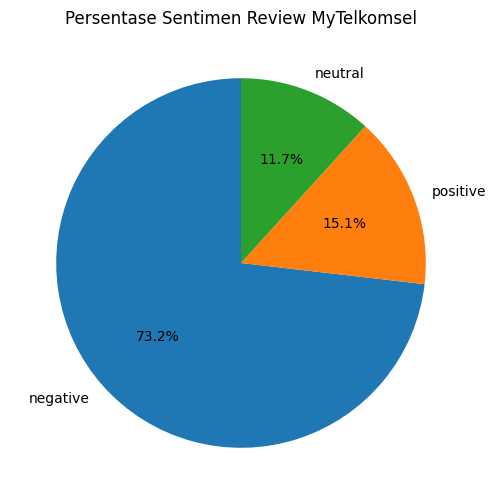

In [28]:
sentiment_count = df['sentiment'].value_counts()

plt.figure(figsize=(6,6))

sentiment_count.plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,
    ylabel=''
)

plt.title('Persentase Sentimen Review MyTelkomsel')
plt.show()

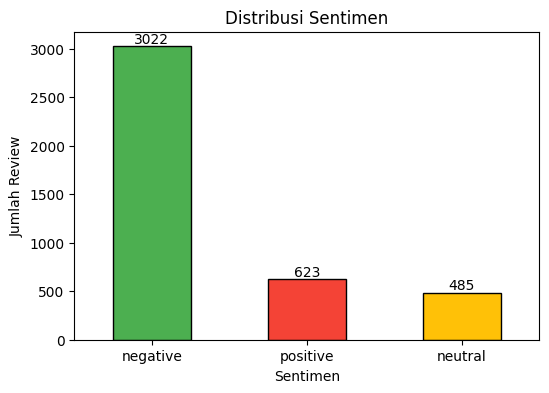

In [29]:
sentiment = df['sentiment'].value_counts()

plt.figure(figsize=(6,4))
ax = sentiment.plot(
    kind='bar',
    color=['#4CAF50','#F44336','#FFC107'],
    edgecolor='black'
)

plt.title("Distribusi Sentimen")
plt.xlabel("Sentimen")
plt.ylabel("Jumlah Review")
plt.xticks(rotation=0)

for p in ax.patches:
    ax.annotate(
        str(int(p.get_height())),
        (p.get_x()+p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom'
    )

plt.show()

##WordCloud

In [30]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

visual_stopwords = custom_stopword.union({
    "telkomsel",
    "mytelkomsel",
    "aplikasi",
    "jadi",
    "buat",
    "kalau",
    "sangat",
    "banyak",
    "apa",
    "padahal",
    "sama",
    "makin",
    "lebih",
    "selalu",
    "sering",
    "sekali",
    "beli",
    "harga",
    "paket",
    "kuota",
    "data"
})

def plot_wordcloud(sentiment):
    text = []

    for tokens in df[df["sentiment"] == sentiment]["stemming"]:
        words = [
            word for word in tokens.split()
            if word not in visual_stopwords
        ]
        text.extend(words)

    wc = WordCloud(
        width=1000,
        height=500,
        background_color="white"
    ).generate(" ".join(text))

    plt.figure(figsize=(12,6))
    plt.imshow(wc)
    plt.axis("off")
    plt.title(f"WordCloud Sentimen {sentiment.capitalize()}")
    plt.show()

####WordCloud Positive

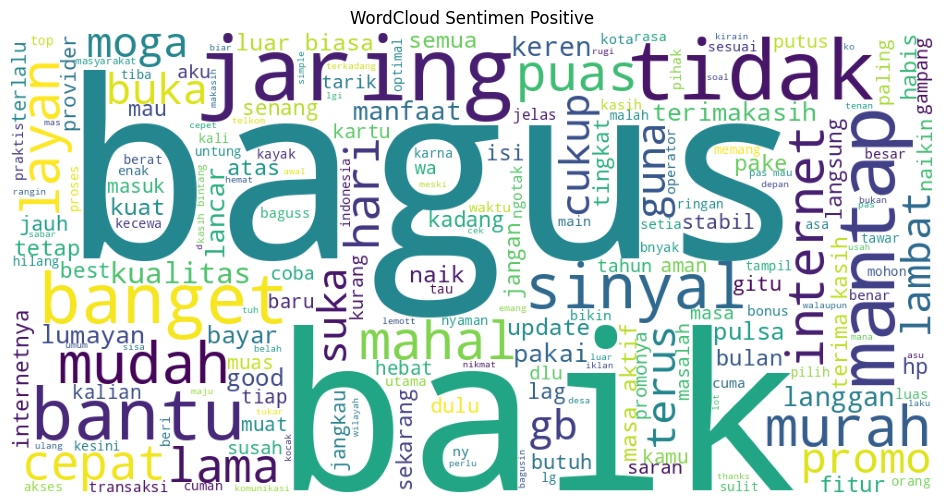

In [31]:
plot_wordcloud("positive")

###WordCloud Negative

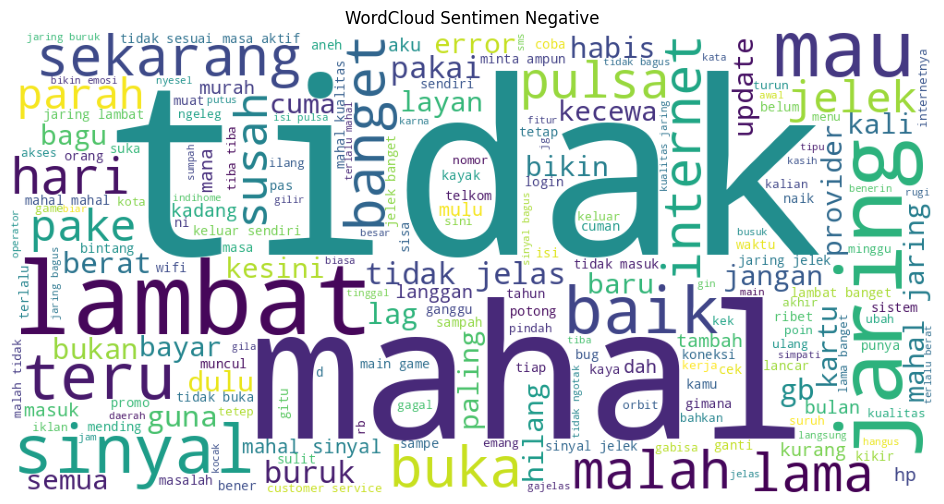

In [32]:
plot_wordcloud("negative")

##Top Frequent Words

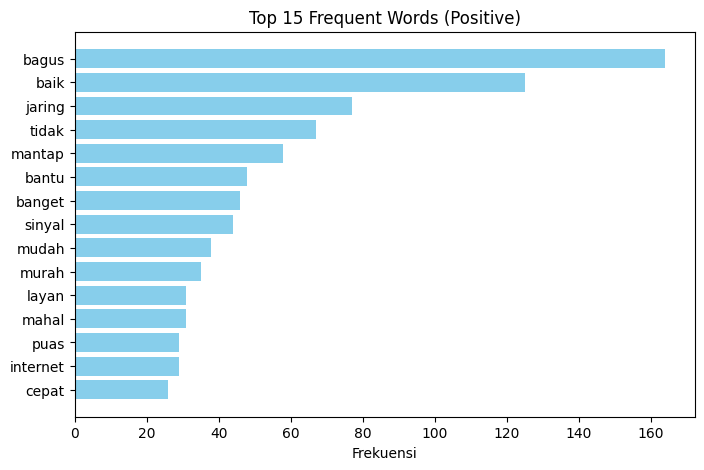

In [33]:
from collections import Counter

positive_words = []

for tokens in df[df["sentiment"]=="positive"]["stemming"]:
    words = [
        word for word in tokens.split()
        if word not in visual_stopwords
    ]
    positive_words.extend(words)

counter = Counter(positive_words)

top = counter.most_common(15)

words = [i[0] for i in top]
freq = [i[1] for i in top]

plt.figure(figsize=(8,5))
plt.barh(words, freq, color="skyblue")
plt.gca().invert_yaxis()
plt.title("Top 15 Frequent Words (Positive)")
plt.xlabel("Frekuensi")
plt.show()

##Bigram

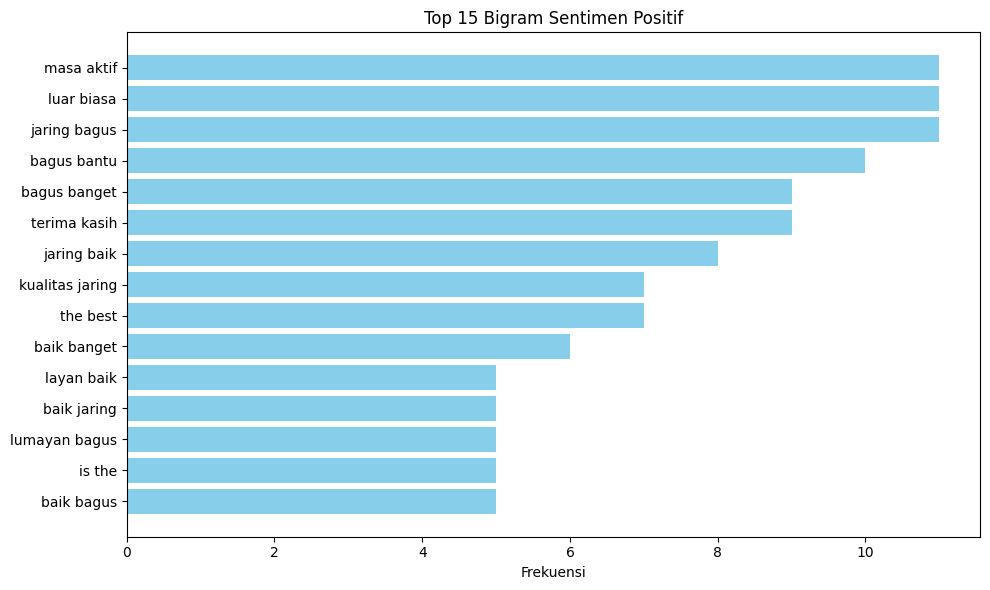

In [34]:
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import numpy as np

# Corpus sentimen positif
positive_corpus = []

for tokens in df[df["sentiment"] == "positive"]["stemming"]:
    words = [
        word for word in tokens.split()
        if word not in visual_stopwords
    ]
    positive_corpus.append(" ".join(words))

# Bigram
vectorizer = CountVectorizer(ngram_range=(2,2))
X = vectorizer.fit_transform(positive_corpus)

# Frekuensi bigram
sum_words = np.array(X.sum(axis=0)).flatten()
bigrams = vectorizer.get_feature_names_out()

# Top 15
top_idx = sum_words.argsort()[::-1][:15]
top_bigrams = bigrams[top_idx]
top_freq = sum_words[top_idx]

# Visualisasi
plt.figure(figsize=(10,6))
plt.barh(top_bigrams[::-1], top_freq[::-1], color="skyblue")
plt.title("Top 15 Bigram Sentimen Positif")
plt.xlabel("Frekuensi")
plt.tight_layout()
plt.show()

#Feature Engineering

##TF-IDF

In [41]:
from sklearn.feature_extraction.text import TfidfVectorizer

X = df['stemming']
y = df['sentiment']

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)
)

X_tfidf = tfidf.fit_transform(X)

print("Shape TF-IDF :", X_tfidf.shape)

Shape TF-IDF : (4130, 5000)


In [42]:
feature_names = tfidf.get_feature_names_out()

print(feature_names[:30])

['abad' 'abal' 'abal abal' 'acara' 'ad' 'ada' 'adain' 'adu' 'aduh'
 'agustus' 'ah' 'ai' 'ai tidak' 'ajar' 'akal' 'akan' 'akhir' 'akhir akhir'
 'akhir aplikasi' 'akhir tidak' 'akhirat' 'akses' 'akses internet' 'aktif'
 'aktif fitur' 'aktif hari' 'aktif kartu' 'aktif kuota' 'aktif paket'
 'aktif rang']


In [43]:
for token in ["abalabal", "ajh", "ahir", "ai"]:
    print(f"\n=== {token} ===")
    print(
        df[df["stemming"].str.contains(token, na=False)][
            ["content", "stemming"]
        ].head()
    )


=== abalabal ===
Empty DataFrame
Columns: [content, stemming]
Index: []

=== ajh ===
                                                                                                                                                                                                                                                                         content  \
316                                                                                                                                                                        Telkomsel makin parajh jaringannya operator lain bagus paket aja malah jaringan sulit miskin jaringan   
914  tolong dong perbaiki bug nya lemot banget susah sekali di buka padahal jaringannya lancar apps ini kalah dengan apk m3 dll jauh lebih lancar dan simpel GK banyak iklan cuma apk Telkomsel ajha yang sangat mengecewakan meskipun di update tetap saja makin susah login...   

                                                                                     

#Count Vectorizer

In [45]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(
    max_features=5000,
    ngram_range=(1,2)
)

X_cv = cv.fit_transform(df['stemming'])

print(X_cv.shape)

(4130, 5000)


#Split Data

In [49]:
# Feature dan label
X = X_tfidf
y = df["sentiment"]

# Split data 80:20
X_train, X_test, train_labels, test_labels = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Data Train :", X_train.shape)
print("Data Test  :", X_test.shape)

Data Train : (3304, 5000)
Data Test  : (826, 5000)


#Modelling dan Evaluation

##Naive Bayes

In [57]:
naive_bayes = MultinomialNB()

naive_bayes.fit(X_train, train_labels)

predictions_nb = naive_bayes.predict(X_test)

accuracy_nb = accuracy_score(test_labels, predictions_nb)

report_nb = classification_report(test_labels, predictions_nb)

print(f"Akurasi Naive Bayes : {accuracy_nb:.4f}\n")
print("Classification Report:")
print(report_nb)

Akurasi Naive Bayes : 0.7930

Classification Report:
              precision    recall  f1-score   support

    negative       0.78      1.00      0.88       604
     neutral       0.00      0.00      0.00        97
    positive       0.91      0.42      0.57       125

    accuracy                           0.79       826
   macro avg       0.57      0.47      0.48       826
weighted avg       0.71      0.79      0.73       826



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [58]:
from sklearn.metrics import classification_report

report_nb = classification_report(
    test_labels,
    predictions_nb,
    output_dict=True
)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


###Confusion Matrix Naive Bayes

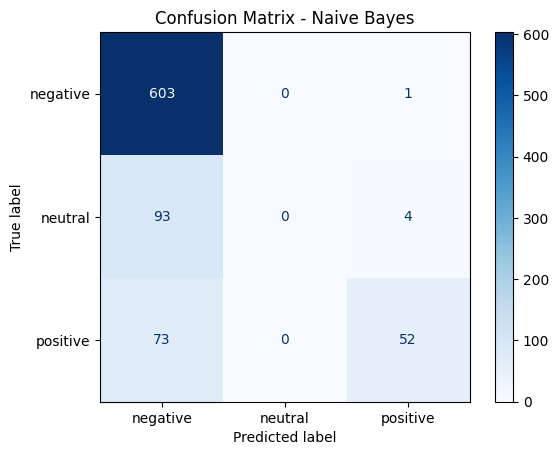

In [65]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    naive_bayes,
    X_test,
    test_labels,
    cmap="Blues"
)

plt.title("Confusion Matrix - Naive Bayes")
plt.show()

##Logistic Regression

In [51]:
logistic_regression = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_regression.fit(X_train, train_labels)

predictions_lr = logistic_regression.predict(X_test)

accuracy_lr = accuracy_score(test_labels, predictions_lr)

report_lr = classification_report(test_labels, predictions_lr)

print(f"Akurasi Logistic Regression : {accuracy_lr:.4f}\n")
print("Classification Report:")
print(report_lr)

Akurasi Logistic Regression : 0.8523

Classification Report:
              precision    recall  f1-score   support

    negative       0.85      0.99      0.91       604
     neutral       0.85      0.18      0.29        97
    positive       0.89      0.72      0.80       125

    accuracy                           0.85       826
   macro avg       0.86      0.63      0.67       826
weighted avg       0.85      0.85      0.82       826



In [59]:
report_lr = classification_report(
    test_labels,
    predictions_lr,
    output_dict=True
)

###Confusion Matrix Logistic Regression

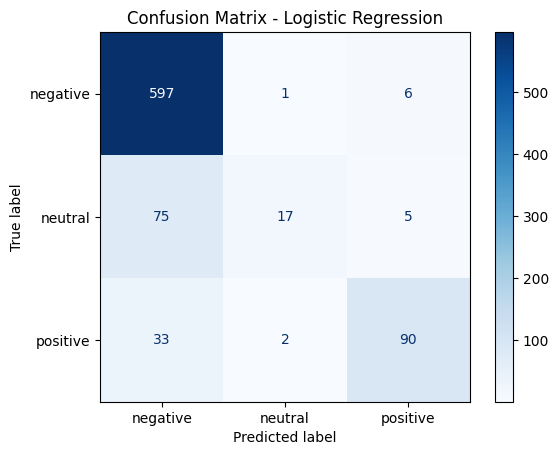

In [66]:
ConfusionMatrixDisplay.from_estimator(
    logistic_regression,
    X_test,
    test_labels,
    cmap="Blues"
)

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

##Support Vector Machine (Linear SVM)

In [53]:
from sklearn.svm import LinearSVC

svm = LinearSVC(random_state=42)

svm.fit(X_train, train_labels)

predictions_svm = svm.predict(X_test)

accuracy_svm = accuracy_score(test_labels, predictions_svm)

report_svm = classification_report(test_labels, predictions_svm)

print(f"Akurasi Support Vector Machine : {accuracy_svm:.4f}\n")
print("Classification Report:")
print(report_svm)

Akurasi Support Vector Machine : 0.8535

Classification Report:
              precision    recall  f1-score   support

    negative       0.87      0.97      0.92       604
     neutral       0.64      0.29      0.40        97
    positive       0.82      0.75      0.79       125

    accuracy                           0.85       826
   macro avg       0.78      0.67      0.70       826
weighted avg       0.84      0.85      0.84       826



In [60]:
report_svm = classification_report(
    test_labels,
    predictions_svm,
    output_dict=True
)

###Confussion Matrix SVM

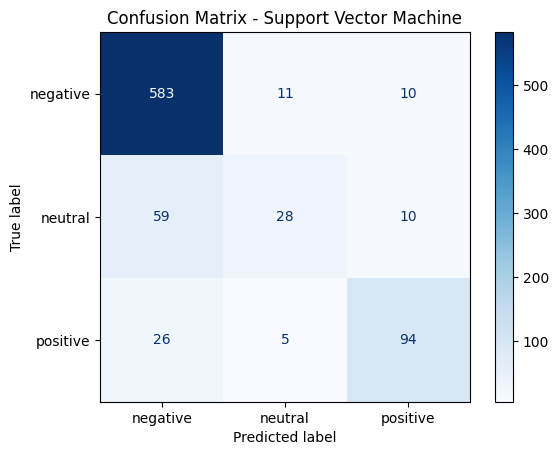

In [67]:
ConfusionMatrixDisplay.from_estimator(
    svm,
    X_test,
    test_labels,
    cmap="Blues"
)

plt.title("Confusion Matrix - Support Vector Machine")
plt.show()

##Decision Tree

In [54]:
decision_tree = DecisionTreeClassifier(random_state=42)

decision_tree.fit(X_train, train_labels)

predictions_dt = decision_tree.predict(X_test)

accuracy_dt = accuracy_score(test_labels, predictions_dt)

report_dt = classification_report(test_labels, predictions_dt)

print(f"Akurasi Decision Tree : {accuracy_dt:.4f}\n")
print("Classification Report:")
print(report_dt)

Akurasi Decision Tree : 0.7712

Classification Report:
              precision    recall  f1-score   support

    negative       0.88      0.84      0.86       604
     neutral       0.39      0.48      0.43        97
    positive       0.65      0.66      0.66       125

    accuracy                           0.77       826
   macro avg       0.64      0.66      0.65       826
weighted avg       0.79      0.77      0.78       826



In [62]:
report_dt = classification_report(
    test_labels,
    predictions_dt,
    output_dict=True
)

###Confusion Matrix Decission Tree

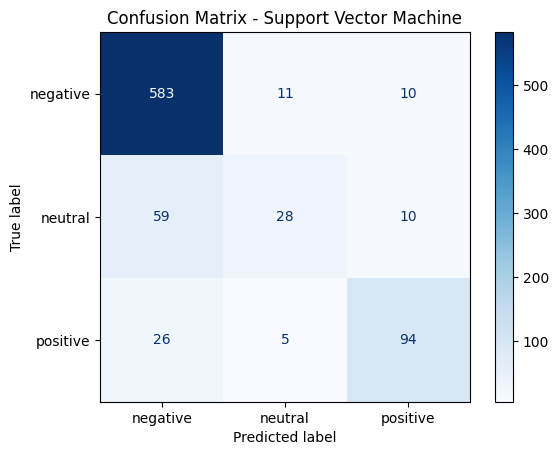

In [68]:
ConfusionMatrixDisplay.from_estimator(
    svm,
    X_test,
    test_labels,
    cmap="Blues"
)

plt.title("Confusion Matrix - Support Vector Machine")
plt.show()

##Perbandingan Model

In [69]:
comparison = pd.DataFrame({
    "Model": [
        "Naive Bayes",
        "Logistic Regression",
        "Support Vector Machine",
        "Decision Tree"
    ],
    "Accuracy": [
        accuracy_nb,
        accuracy_lr,
        accuracy_svm,
        accuracy_dt
    ],
    "Precision": [
        report_nb["weighted avg"]["precision"],
        report_lr["weighted avg"]["precision"],
        report_svm["weighted avg"]["precision"],
        report_dt["weighted avg"]["precision"]
    ],
    "Recall": [
        report_nb["weighted avg"]["recall"],
        report_lr["weighted avg"]["recall"],
        report_svm["weighted avg"]["recall"],
        report_dt["weighted avg"]["recall"]
    ],
    "F1-Score": [
        report_nb["weighted avg"]["f1-score"],
        report_lr["weighted avg"]["f1-score"],
        report_svm["weighted avg"]["f1-score"],
        report_dt["weighted avg"]["f1-score"]
    ]
})

comparison = comparison.round(4)

comparison

,Model,Accuracy,Precision,Recall,F1-Score
0,Naive Bayes,0.7930,0.7114,0.7930,0.7288
1,Logistic Regression,0.8523,0.8539,0.8523,0.8216
2,Support Vector Machine,0.8535,0.8377,0.8535,0.8360
3,Decision Tree,0.7712,0.7867,0.7712,0.7779


Berdasarkan hasil evaluasi, algoritma Support Vector Machine (SVM) dipilih sebagai model terbaik karena memiliki performa paling baik dibandingkan algoritma lainnya. SVM memperoleh accuracy sebesar 85,35%, yang berarti sekitar 85 dari 100 data berhasil diprediksi dengan benar. Selain itu, recall sebesar 85,35% menunjukkan bahwa model mampu mengenali sebagian besar data pada setiap kelas sentimen. Nilai F1-score sebesar 83,60% juga merupakan yang tertinggi, yang menandakan bahwa model memiliki keseimbangan yang baik antara ketepatan prediksi (precision) dan kemampuan menemukan data yang benar (recall). Meskipun Logistic Regression memiliki nilai precision sedikit lebih tinggi, selisihnya sangat kecil. Secara keseluruhan, SVM memberikan hasil yang paling konsisten sehingga dipilih sebagai model terbaik untuk klasifikasi sentimen ulasan aplikasi MyTelkomsel.

#Save Model

In [70]:
import joblib

joblib.dump(svm,"svm_model.pkl")
joblib.dump(tfidf,"tfidf.pkl")

['tfidf.pkl']

In [74]:
from google.colab import files

files.download("svm_model.pkl")
files.download("tfidf.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>